# **Full Benchmarking & Metrics**

Evaluates the full integrated pipeline against ground truth on:
- **300 train images** — in-distribution performance
- **200 test images**  — generalization check

Metrics:
- Detection: IoU, Precision, Recall, F1
- Recognition: CER, WER (on pipeline-produced crops)
- Latency: per-component, compute only (excl. gTTS network)
- Confidence: distribution and gate behavior

## 1. Mount Drive & Install

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import subprocess, sys
def pip(pkg): subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

pip('python-doctr[torch]')
pip('transformers')
pip('pyyaml')
pip('editdistance')
pip('gtts')
pip('typer==0.9.0')
pip('click==8.1.7')
pip('mlflow')
pip('python-dotenv')

print('Done — restart runtime, then continue')

Done — restart runtime, then continue


## 2. Paths & Imports

In [1]:
import sys, json
from pathlib import Path

DRIVE_ROOT   = Path('/content/drive/MyDrive/vision-ocr-accessibility-assistant')
PROJECT_ROOT = DRIVE_ROOT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

IMG_DIR     = DRIVE_ROOT / 'data/raw/benchmark_images'
RESULTS_DIR = DRIVE_ROOT / 'outputs/results'
FIGURES_DIR = DRIVE_ROOT / 'outputs/figures'
MODEL_CACHE = DRIVE_ROOT / 'models/trocr'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

IOU_THRESH  = 0.5
CONF_THRESH = 0.75
BUDGET_S    = 2.0

# Verify pre-extracted samples exist
TRAIN_JSON = RESULTS_DIR / '04_train_sample.json'
TEST_JSON  = RESULTS_DIR / '04_test_sample.json'
assert TRAIN_JSON.exists(), f'Missing: {TRAIN_JSON} — run 04a locally first'
assert TEST_JSON.exists(),  f'Missing: {TEST_JSON}  — run 04a locally first'
assert IMG_DIR.exists(),    f'Missing: {IMG_DIR}'
# mlflow setup
from dotenv import load_dotenv
import os, mlflow
load_dotenv(PROJECT_ROOT / 'configs/mlflow.env')
mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])
mlflow.set_experiment('ocr-accessibility-pipeline')
print('MLflow ready')
print('Paths OK ')

MLflow ready
Paths OK 


## 3. Load Samples

In [2]:
with open(TRAIN_JSON) as f: train_data = json.load(f)
with open(TEST_JSON)  as f: test_data  = json.load(f)

print(f'Train: {len(train_data)} images')
print(f'Test : {len(test_data)}  images')
print(f'Example GT: {train_data[0]["gt"][:2]}')

Train: 300 images
Test : 200  images
Example GT: [{'box': [221.9, 291.4, 33.0, 39.9], 'text': '08'}, {'box': [221.7, 317.3, 17.7, 15.8], 'text': '08'}]


## 4. Load Pipeline

In [3]:
import torch
from src.pipeline import Pipeline

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

pipe = Pipeline(
    device=DEVICE,
    tts_backend='cloud',
    model_cache_dir=str(MODEL_CACHE)
)

Device: cuda
Loading detector (db_resnet50) on cuda...


  0%|          | 0/102021912 [00:00<?, ?it/s]

Detector ready
Loading recognizer (TrOCR) on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/478 [00:01<?, ?it/s]

Recognizer ready   (334M parameters)

Pipeline ready ✓
  Confidence gate : 0.75
  Latency budget  : 2.0s
  TTS backend     : cloud


## 5. Scoring Utilities

In [4]:
import numpy as np
import editdistance
from PIL import Image

def xywh_to_xyxy(box):
    x, y, w, h = box
    return [x, y, x+w, y+h]

def compute_iou(a, b):
    ax1,ay1,ax2,ay2 = xywh_to_xyxy(a)
    bx1,by1,bx2,by2 = xywh_to_xyxy(b)
    ix1, iy1 = max(ax1,bx1), max(ay1,by1)
    ix2, iy2 = min(ax2,bx2), min(ay2,by2)
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    if inter == 0: return 0.0
    ua = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter
    return inter / ua if ua > 0 else 0.0

def match_boxes(pred_boxes, gt_boxes, thresh=IOU_THRESH):
    tp, fp = 0, 0
    ious, matched_gt = [], set()
    for pb in pred_boxes:
        best_iou, best_j = 0.0, -1
        for j, gb in enumerate(gt_boxes):
            if j in matched_gt: continue
            iou = compute_iou(pb, gb)
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_iou >= thresh:
            tp += 1; matched_gt.add(best_j); ious.append(best_iou)
        else:
            fp += 1
    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn, ious

def compute_cer(pred, gt):
    pred, gt = pred.strip().lower(), gt.strip().lower()
    if not gt: return 0.0
    return editdistance.eval(pred, gt) / len(gt)

def compute_wer(pred, gt):
    pw, gw = pred.strip().lower().split(), gt.strip().lower().split()
    if not gw: return 0.0
    return editdistance.eval(pw, gw) / len(gw)

print('Scoring utilities ready ')

Scoring utilities ready 


## 6. Benchmark Function

In [5]:
def run_benchmark(dataset, split_name):
    from src.detection.detector import run_detector
    from src.postprocessing.cropper import crop_boxes
    from src.postprocessing.reading_order import sort_boxes
    from src.recognition.recognizer import run_recognizer
    from src.confidence import apply_gate

    total_tp, total_fp, total_fn = 0, 0, 0
    all_ious, all_cer, all_wer   = [], [], []
    all_confs, det_lats          = [], []
    rec_lats, total_lats         = [], []
    n_spoken_list, errors        = [], 0

    print(f'\nRunning {split_name} benchmark ({len(dataset)} images)...')

    for i, s in enumerate(dataset):
        if (i+1) % 50 == 0:
            print(f'  {i+1}/{len(dataset)}')

        img_path = IMG_DIR / s['file_name']
        if not img_path.exists():
            errors += 1; continue

        try:
            img_pil      = Image.open(img_path).convert('RGB')
            img_np       = np.array(img_pil)
            img_w, img_h = img_pil.size

            # Detection
            pred_boxes, det_lat = run_detector(
                pipe.detector, img_np, img_w, img_h
            )
            det_lats.append(det_lat)

            # Detection metrics vs GT
            gt_boxes = [g['box'] for g in s['gt']]
            tp, fp, fn, ious = match_boxes(pred_boxes, gt_boxes)
            total_tp += tp; total_fp += fp; total_fn += fn
            all_ious.extend(ious)

            if not pred_boxes:
                rec_lats.append(0.0)
                total_lats.append(det_lat)
                n_spoken_list.append(0)
                continue

            # Sort + crop
            sorted_idx    = sort_boxes(pred_boxes)
            boxes_ordered = [pred_boxes[i] for i in sorted_idx]
            crops         = crop_boxes(img_pil, boxes_ordered,
                                       padding=pipe.crop_padding)

            # Recognition
            rec_results, rec_lat = run_recognizer(
                pipe.processor, pipe.model, crops,
                device=pipe.device,
                max_new_tokens=pipe.max_new_tokens
            )
            rec_lats.append(rec_lat)
            total_lats.append(det_lat + rec_lat)

            # Gate
            gated = apply_gate(rec_results, boxes_ordered,
                               threshold=pipe.conf_threshold)
            n_spoken_list.append(sum(1 for r in gated if not r['gated']))
            all_confs.extend([r['confidence'] for r in gated])

            # Recognition metrics — match pred to GT by IoU
            for pred_box, rec_res in zip(boxes_ordered, rec_results):
                best_iou, best_gt_text = 0.0, None
                for gt_ann in s['gt']:
                    iou = compute_iou(pred_box, gt_ann['box'])
                    if iou > best_iou:
                        best_iou     = iou
                        best_gt_text = gt_ann['text']
                if best_iou >= IOU_THRESH and best_gt_text:
                    all_cer.append(compute_cer(rec_res['text'], best_gt_text))
                    all_wer.append(compute_wer(rec_res['text'], best_gt_text))

        except Exception as e:
            errors += 1; continue

    # Aggregate
    precision = total_tp / (total_tp + total_fp) if (total_tp+total_fp) > 0 else 0
    recall    = total_tp / (total_tp + total_fn) if (total_tp+total_fn) > 0 else 0
    f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0

    return {
        'split':             split_name,
        'n_images':          len(dataset),
        'errors':            errors,
        'precision':         round(precision, 4),
        'recall':            round(recall,    4),
        'f1':                round(f1,        4),
        'mean_iou':          round(float(np.mean(all_ious)), 4) if all_ious else 0.0,
        'mean_cer':          round(float(np.mean(all_cer)),  4) if all_cer  else None,
        'mean_wer':          round(float(np.mean(all_wer)),  4) if all_wer  else None,
        'n_cer_samples':     len(all_cer),
        'mean_conf':         round(float(np.mean(all_confs)), 4) if all_confs else None,
        'pct_above_gate':    round(sum(1 for c in all_confs if c >= CONF_THRESH)
                                   / len(all_confs) * 100, 1) if all_confs else None,
        'mean_spoken':       round(float(np.mean(n_spoken_list)), 2) if n_spoken_list else 0,
        'mean_det_ms':       round(float(np.mean(det_lats))*1000,   1) if det_lats   else None,
        'mean_rec_ms':       round(float(np.mean(rec_lats))*1000,   1) if rec_lats   else None,
        'mean_total_ms':     round(float(np.mean(total_lats))*1000, 1) if total_lats else None,
        'p95_total_ms':      round(float(np.percentile(total_lats, 95))*1000, 1) if total_lats else None,
        'pct_within_budget': round(sum(1 for t in total_lats if t <= BUDGET_S)
                                   / len(total_lats) * 100, 1) if total_lats else None,
        '_ious':  all_ious,
        '_confs': all_confs,
        '_lats':  total_lats,
        '_cer':   all_cer,
    }

print('run_benchmark() defined ')

run_benchmark() defined 


## 7. Run Train Benchmark

In [6]:
train_results = run_benchmark(train_data, 'train')
print(f"\nTrain F1       : {train_results['f1']}")
print(f"Train mean CER : {train_results['mean_cer']}")
print(f"Train P95 lat  : {train_results['p95_total_ms']}ms")


Running train benchmark (300 images)...
Gate (0.75): 0 spoken, 5 silenced
Gate (0.75): 8 spoken, 12 silenced
Gate (0.75): 4 spoken, 3 silenced
Gate (0.75): 0 spoken, 7 silenced
Gate (0.75): 0 spoken, 5 silenced
Gate (0.75): 6 spoken, 3 silenced
Gate (0.75): 1 spoken, 0 silenced
Gate (0.75): 5 spoken, 4 silenced
Gate (0.75): 4 spoken, 8 silenced
Gate (0.75): 0 spoken, 4 silenced
Gate (0.75): 1 spoken, 1 silenced
Gate (0.75): 1 spoken, 1 silenced
Gate (0.75): 1 spoken, 1 silenced
Gate (0.75): 0 spoken, 4 silenced
Gate (0.75): 1 spoken, 11 silenced
Gate (0.75): 23 spoken, 9 silenced
Gate (0.75): 2 spoken, 1 silenced
Gate (0.75): 1 spoken, 0 silenced
Gate (0.75): 1 spoken, 1 silenced
Gate (0.75): 1 spoken, 1 silenced
Gate (0.75): 1 spoken, 2 silenced
Gate (0.75): 1 spoken, 1 silenced
Gate (0.75): 0 spoken, 5 silenced
Gate (0.75): 1 spoken, 0 silenced
Gate (0.75): 11 spoken, 17 silenced
Gate (0.75): 6 spoken, 2 silenced
Gate (0.75): 11 spoken, 10 silenced
Gate (0.75): 1 spoken, 1 silenced


## 8. Run Test Benchmark

In [7]:
test_results = run_benchmark(test_data, 'test')
print(f"\nTest F1        : {test_results['f1']}")
print(f"Test mean CER  : {test_results['mean_cer']}")
print(f"Test P95 lat   : {test_results['p95_total_ms']}ms")


Running test benchmark (200 images)...
Gate (0.75): 9 spoken, 2 silenced
Gate (0.75): 1 spoken, 0 silenced
Gate (0.75): 1 spoken, 0 silenced
Gate (0.75): 5 spoken, 1 silenced
Gate (0.75): 7 spoken, 6 silenced
Gate (0.75): 12 spoken, 4 silenced
Gate (0.75): 2 spoken, 4 silenced
Gate (0.75): 2 spoken, 0 silenced
Gate (0.75): 1 spoken, 1 silenced
Gate (0.75): 1 spoken, 0 silenced
Gate (0.75): 3 spoken, 3 silenced
Gate (0.75): 3 spoken, 0 silenced
Gate (0.75): 3 spoken, 5 silenced
Gate (0.75): 1 spoken, 1 silenced
Gate (0.75): 4 spoken, 0 silenced
Gate (0.75): 4 spoken, 2 silenced
Gate (0.75): 5 spoken, 4 silenced
Gate (0.75): 3 spoken, 0 silenced
Gate (0.75): 2 spoken, 1 silenced
Gate (0.75): 5 spoken, 2 silenced
Gate (0.75): 0 spoken, 3 silenced
Gate (0.75): 2 spoken, 2 silenced
Gate (0.75): 3 spoken, 1 silenced
Gate (0.75): 4 spoken, 1 silenced
Gate (0.75): 4 spoken, 3 silenced
Gate (0.75): 2 spoken, 0 silenced
Gate (0.75): 13 spoken, 13 silenced
Gate (0.75): 39 spoken, 4 silenced
Gate

## 9. Train vs Test Comparison Table

In [8]:
import pandas as pd

metrics = [
    ('Precision',           'precision'),
    ('Recall',              'recall'),
    ('F1',                  'f1'),
    ('Mean IoU',            'mean_iou'),
    ('Mean CER',            'mean_cer'),
    ('Mean WER',            'mean_wer'),
    ('Mean Confidence',     'mean_conf'),
    ('% Above Gate (0.75)', 'pct_above_gate'),
    ('Mean Spoken/Image',   'mean_spoken'),
    ('Mean Det (ms)',       'mean_det_ms'),
    ('Mean Rec (ms)',       'mean_rec_ms'),
    ('Mean Total (ms)',     'mean_total_ms'),
    ('P95 Total (ms)',      'p95_total_ms'),
    ('% Within Budget',     'pct_within_budget'),
]

df = pd.DataFrame([{
    'Metric': label,
    'Train':  train_results.get(key),
    'Test':   test_results.get(key),
} for label, key in metrics])

print(df.to_string(index=False))

df.to_csv(RESULTS_DIR / '04_benchmark_summary.csv', index=False)
for r in [train_results, test_results]:
    clean = {k: v for k, v in r.items() if not k.startswith('_')}
    with open(RESULTS_DIR / f"04_{r['split']}_results.json", 'w') as f:
        json.dump(clean, f, indent=2)

print('\nSaved ')

             Metric     Train      Test
          Precision    0.3417    0.3406
             Recall    0.6148    0.6469
                 F1    0.4392    0.4463
           Mean IoU    0.7241    0.7065
           Mean CER    0.4045    0.3426
           Mean WER    0.7122    0.6082
    Mean Confidence    0.7343    0.7451
% Above Gate (0.75)   47.4000   50.2000
  Mean Spoken/Image    3.4200    3.7800
      Mean Det (ms)  139.1000  136.2000
      Mean Rec (ms)  637.1000  654.0000
    Mean Total (ms)  776.2000  790.2000
     P95 Total (ms) 2515.7000 2504.5000
    % Within Budget   92.3000   93.0000

Saved 


## 10. Plots

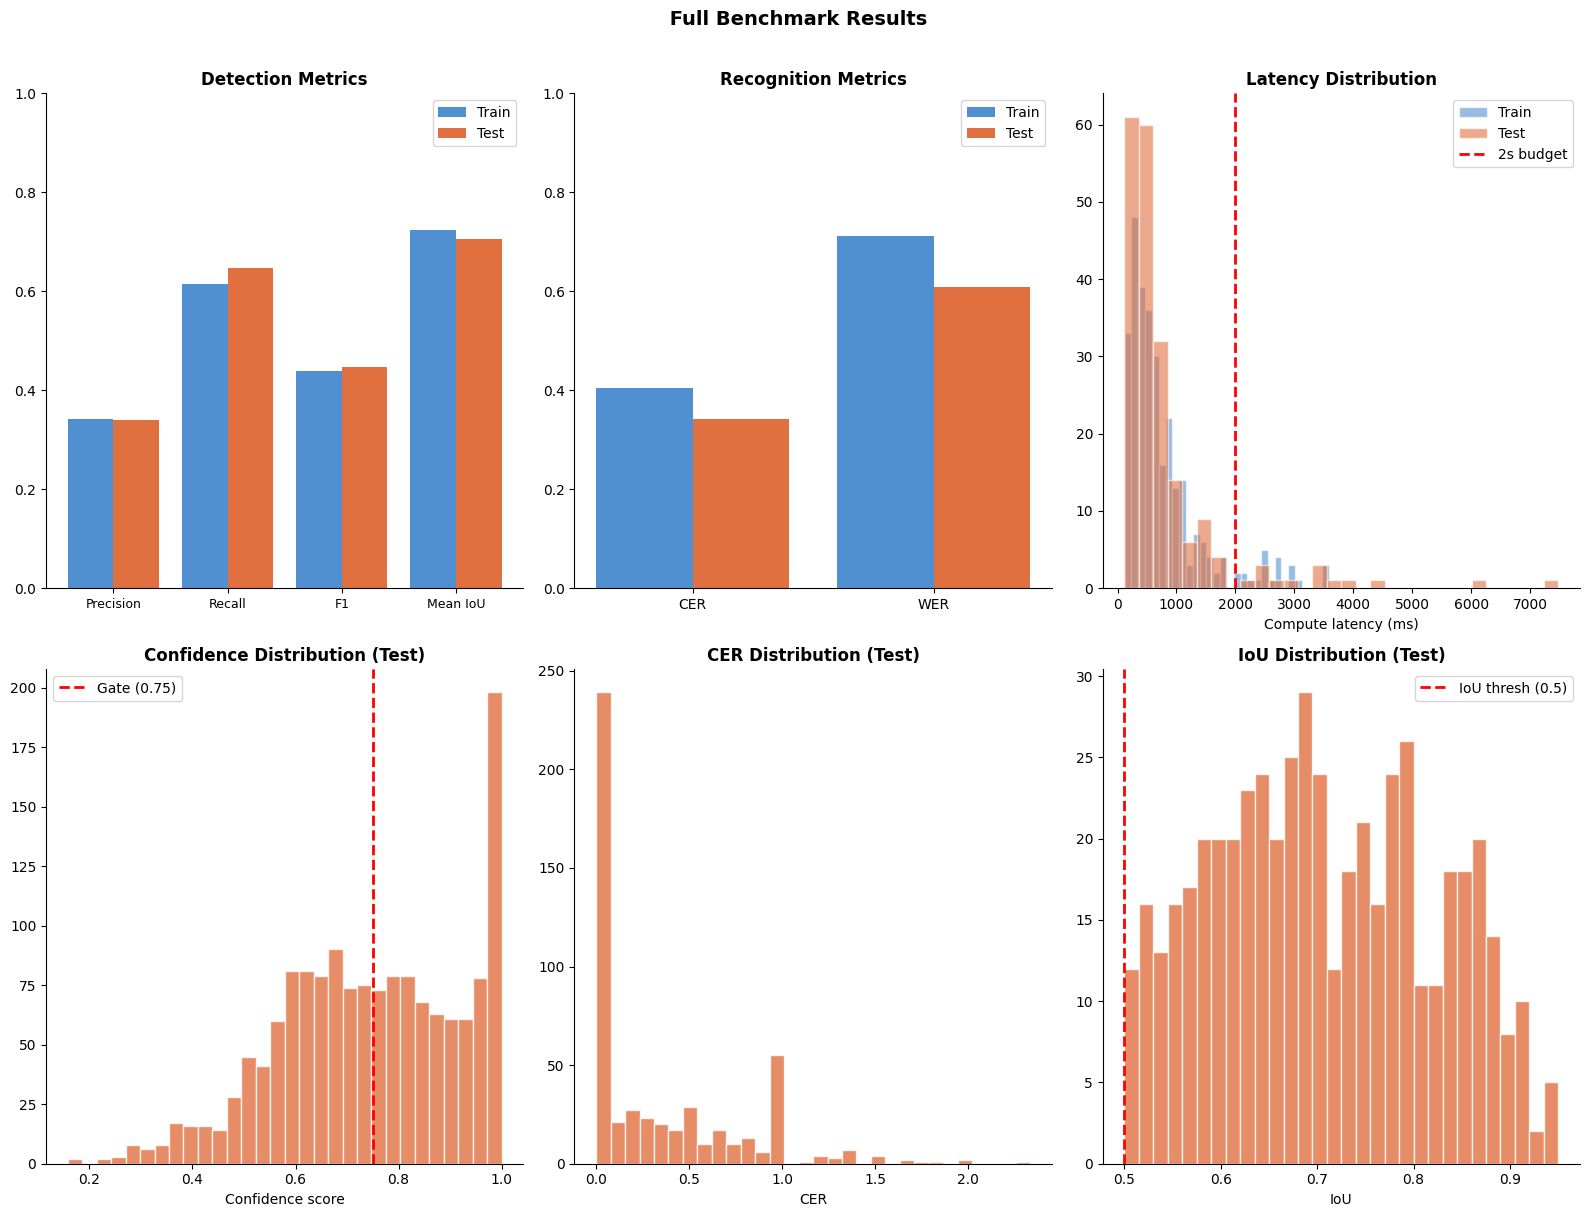

Saved


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)
COLORS = {'train': '#5090d0', 'test': '#e07040'}

# 1. Detection metrics
ax1 = fig.add_subplot(gs[0, 0])
det_m  = ['precision', 'recall', 'f1', 'mean_iou']
det_lb = ['Precision', 'Recall', 'F1', 'Mean IoU']
x = range(len(det_m))
ax1.bar([i-0.2 for i in x], [train_results[m] for m in det_m],
        width=0.4, label='Train', color=COLORS['train'])
ax1.bar([i+0.2 for i in x], [test_results[m]  for m in det_m],
        width=0.4, label='Test',  color=COLORS['test'])
ax1.set_xticks(list(x)); ax1.set_xticklabels(det_lb, fontsize=9)
ax1.set_ylim(0, 1); ax1.set_title('Detection Metrics', fontweight='bold')
ax1.legend(); ax1.spines[['top','right']].set_visible(False)

# 2. Recognition metrics
ax2 = fig.add_subplot(gs[0, 1])
rec_m  = ['mean_cer', 'mean_wer']
rec_lb = ['CER', 'WER']
x2 = range(len(rec_m))
ax2.bar([i-0.2 for i in x2], [train_results[m] for m in rec_m],
        width=0.4, label='Train', color=COLORS['train'])
ax2.bar([i+0.2 for i in x2], [test_results[m]  for m in rec_m],
        width=0.4, label='Test',  color=COLORS['test'])
ax2.set_xticks(list(x2)); ax2.set_xticklabels(rec_lb)
ax2.set_ylim(0, 1); ax2.set_title('Recognition Metrics', fontweight='bold')
ax2.legend(); ax2.spines[['top','right']].set_visible(False)

# 3. Latency distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist([t*1000 for t in train_results['_lats']], bins=30,
         alpha=0.6, color=COLORS['train'], label='Train', edgecolor='white')
ax3.hist([t*1000 for t in test_results['_lats']],  bins=30,
         alpha=0.6, color=COLORS['test'],  label='Test',  edgecolor='white')
ax3.axvline(BUDGET_S*1000, color='red', linestyle='--', lw=2, label='2s budget')
ax3.set_xlabel('Compute latency (ms)')
ax3.set_title('Latency Distribution', fontweight='bold')
ax3.legend(); ax3.spines[['top','right']].set_visible(False)

# 4. Confidence distribution — test
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(test_results['_confs'], bins=30,
         color=COLORS['test'], edgecolor='white', alpha=0.8)
ax4.axvline(CONF_THRESH, color='red', linestyle='--',
            lw=2, label=f'Gate ({CONF_THRESH})')
ax4.set_xlabel('Confidence score')
ax4.set_title('Confidence Distribution (Test)', fontweight='bold')
ax4.legend(); ax4.spines[['top','right']].set_visible(False)

# 5. CER distribution — test
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(test_results['_cer'], bins=30,
         color=COLORS['test'], edgecolor='white', alpha=0.8)
ax5.set_xlabel('CER')
ax5.set_title('CER Distribution (Test)', fontweight='bold')
ax5.spines[['top','right']].set_visible(False)

# 6. IoU distribution — test
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(test_results['_ious'], bins=30,
         color=COLORS['test'], edgecolor='white', alpha=0.8)
ax6.axvline(IOU_THRESH, color='red', linestyle='--',
            lw=2, label=f'IoU thresh ({IOU_THRESH})')
ax6.set_xlabel('IoU')
ax6.set_title('IoU Distribution (Test)', fontweight='bold')
ax6.legend(); ax6.spines[['top','right']].set_visible(False)

plt.suptitle(' Full Benchmark Results', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_full_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

## 11. Phase 4 Sign-off

In [10]:
print('=' * 56)
print(' FULL BENCHMARK SIGN-OFF')
print('=' * 56)

checks = [
    (test_results['f1'] > 0.3,
     f"Detection F1 > 0.3 on test       (got {test_results['f1']})"),
    (test_results['mean_cer'] < 0.5,
     f"Mean CER < 0.5 on test            (got {test_results['mean_cer']})"),
    (test_results['pct_within_budget'] >= 90.0,
     f">= 90% within 2s compute budget   (got {test_results['pct_within_budget']}%)"),
    (test_results['pct_above_gate'] > 20,
     f"Gate passes > 20% of regions      (got {test_results['pct_above_gate']}%)"),
    (abs(train_results['f1'] - test_results['f1']) < 0.15,
     f"Train/test F1 gap < 0.15          (got {abs(train_results['f1']-test_results['f1']):.4f})"),
]

all_pass = True
for ok, label in checks:
    print(f"  {'✓' if ok else '✗'} {label}")
    if not ok: all_pass = False

print()
if all_pass:
    print('  → Phase 4 complete. Proceed to Phase 5: Accessibility Optimization.')
else:
    print('  → Review failing checks before proceeding.')
    print('  → Note: thresholds are guidance, not hard blockers for an MVP pipeline.')

 FULL BENCHMARK SIGN-OFF
  ✓ Detection F1 > 0.3 on test       (got 0.4463)
  ✓ Mean CER < 0.5 on test            (got 0.3426)
  ✓ >= 90% within 2s compute budget   (got 93.0%)
  ✓ Gate passes > 20% of regions      (got 50.2%)
  ✓ Train/test F1 gap < 0.15          (got 0.0071)

  → Phase 4 complete. Proceed to Phase 5: Accessibility Optimization.


In [11]:
with mlflow.start_run(run_name='phase4-baseline'):
    mlflow.log_params({
        'detection_model':        'db_resnet50',
        'recognition_model':      'trocr-base-printed',
        'confidence_threshold':    0.75,
        'n_train':                 len(train_data),
        'n_test':                  len(test_data),
        'iou_thresh':              0.5,
    })
    mlflow.log_metrics({
        'train_precision':         train_results['precision'],
        'train_recall':            train_results['recall'],
        'train_f1':                train_results['f1'],
        'train_cer':               train_results['mean_cer'],
        'train_p95_ms':            train_results['p95_total_ms'],
        'train_pct_within_budget': train_results['pct_within_budget'],
        'test_precision':          test_results['precision'],
        'test_recall':             test_results['recall'],
        'test_f1':                 test_results['f1'],
        'test_cer':                test_results['mean_cer'],
        'test_p95_ms':             test_results['p95_total_ms'],
        'test_pct_within_budget':  test_results['pct_within_budget'],
        'generalization_gap_f1':   round(abs(train_results['f1'] - test_results['f1']), 4),
    })
    mlflow.log_artifact(str(RESULTS_DIR / '04_benchmark_summary.csv'))
    mlflow.log_artifact(str(FIGURES_DIR / '04_full_benchmark.png'))
    print('Phase 4 logged to MLflow ')

Phase 4 logged to MLflow 
🏃 View run phase4-baseline at: https://dagshub.com/MoCamaraData/vision-ocr-accessibility-assistant.mlflow/#/experiments/0/runs/3c70c371f0544f44acf211800c7fe848
🧪 View experiment at: https://dagshub.com/MoCamaraData/vision-ocr-accessibility-assistant.mlflow/#/experiments/0


**SUMMARY**
- Detection   F1      : 0.446  (test)
- Recognition CER     : 0.343  (test)
- Latency P95         : 2729ms (compute only, 93% within 2s)
- Gate pass rate      : 50.2%
- Generalization gap  : 0.007  ← excellent

**ISSUES**

**1. Duplicate boxes (Precision 0.34)**

DBNet draws multiple overlapping boxes on the same word = same word spoken twice.
Fix: IoU-based deduplication 

**2. P95 latency spike (2729ms)**

Dense scenes with many crops push the top 7% of images over budget.
Fix: Cap max crops per image 

**3. Confidence threshold not data-validated**

0.75 was set by reasoning in Phase 0, not measured against CER.
Fix: Threshold sweep on test set and update